# Climate Data Analysis & Visualization

This notebook looks at global surface temperature changes using `pandas`, `numpy`, and `matplotlib`. The data was originally compiled by the UN's Food and Agriculture Organization (FAO) and downloaded through the [IMF Climate Data Portal](https://climatedata.imf.org/datasets/4063314923d74187be9596f10d034914_0/about). It tracks yearly temperature changes compared to a 1951–1980 baseline for countries around the world.

The goal of this project was to clean and prepare the data, then look at temperature trends across countries and regions. I also compared changes over different time periods to get a better idea of how temperatures have changed globally.


## Part 1. Preparing the Data

First, I imported `pandas` and `numpy`.

In [5]:
import pandas as pd
import numpy as np

The dataset contains annual estimates of surface temperature change since a 1951–1980 baseline for each country. I loaded it into a DataFrame.

In [7]:
temp_data_df = pd.read_csv("data/Annual_Surface_Temperature_Change.csv")

I inspected the first 5 rows of the raw data to get a sense of its structure.

In [8]:
temp_data_df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243


The table was pretty wide, so I printed the column names to understand what information was included.

In [9]:
print(list(temp_data_df.columns))

['ObjectId', 'Country', 'ISO2', 'ISO3', 'Indicator', 'Unit', 'Source', 'CTS_Code', 'CTS_Name', 'CTS_Full_Descriptor', 'F1961', 'F1962', 'F1963', 'F1964', 'F1965', 'F1966', 'F1967', 'F1968', 'F1969', 'F1970', 'F1971', 'F1972', 'F1973', 'F1974', 'F1975', 'F1976', 'F1977', 'F1978', 'F1979', 'F1980', 'F1981', 'F1982', 'F1983', 'F1984', 'F1985', 'F1986', 'F1987', 'F1988', 'F1989', 'F1990', 'F1991', 'F1992', 'F1993', 'F1994', 'F1995', 'F1996', 'F1997', 'F1998', 'F1999', 'F2000', 'F2001', 'F2002', 'F2003', 'F2004', 'F2005', 'F2006', 'F2007', 'F2008', 'F2009', 'F2010', 'F2011', 'F2012', 'F2013', 'F2014', 'F2015', 'F2016', 'F2017', 'F2018', 'F2019', 'F2020', 'F2021', 'F2022']


Most columns represent an individual year, but a few (like "Indicator" and "Unit") were redundant metadata that didn't add analytical value, so I dropped them to make the dataset easier to work with.

In [10]:
temp_data_df = temp_data_df.drop(columns=['ObjectId','Indicator','Unit','Source','CTS_Code','CTS_Name','CTS_Full_Descriptor'])
temp_data_df.head()

,Country,ISO2,ISO3,F1961,F1962,F1963,F1964,F1965,F1966,F1967,...,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,"Afghanistan, Islamic Rep. of",AF,AFG,-0.113,-0.164,0.847,-0.764,-0.244,0.226,-0.371,...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,Albania,AL,ALB,0.627,0.326,0.075,-0.166,-0.388,0.559,-0.074,...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,Algeria,DZ,DZA,0.164,0.114,0.077,0.250,-0.100,0.433,-0.026,...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,American Samoa,AS,ASM,0.079,-0.042,0.169,-0.140,-0.562,0.181,-0.368,...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,"Andorra, Principality of",AD,AND,0.736,0.112,-0.752,0.308,-0.490,0.415,0.637,...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243


Each year column had an "F" prefix (e.g., `F1961`), qwhich was there to likely force the columns to be read as strings instead of numbers. I renamed the columns to remove that prefix.

In [11]:
new_columns = []
for col in temp_data_df.columns:
    if len(col) > 1 and col[0] == 'F' and col[1:].isdigit():
        new_columns.append(col[1:])
    else:
        new_columns.append(col)

temp_data_df.columns = new_columns
temp_data_df.head()

,Country,ISO2,ISO3,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,"Afghanistan, Islamic Rep. of",AF,AFG,-0.113,-0.164,0.847,-0.764,-0.244,0.226,-0.371,...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,Albania,AL,ALB,0.627,0.326,0.075,-0.166,-0.388,0.559,-0.074,...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,Algeria,DZ,DZA,0.164,0.114,0.077,0.250,-0.100,0.433,-0.026,...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,American Samoa,AS,ASM,0.079,-0.042,0.169,-0.140,-0.562,0.181,-0.368,...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,"Andorra, Principality of",AD,AND,0.736,0.112,-0.752,0.308,-0.490,0.415,0.637,...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243


Since I was focused on more recent trends, I narrowed the dataset down to the years 2000 and onward. I dropped the 1961–1999 columns.

In [12]:
print(list(temp_data_df.columns)[:12])

['Country', 'ISO2', 'ISO3', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969']


I cleaned the data by removing irrelevant fields, renaming columns, and narrowing the date range before beginning the analysis. This made the dataset easier to work with and kept the analysis focused on the years I wanted to look at.

## Part 2. Temperature Change

With the data cleaned, I moved on to analysis.

I started by pulling out the data for the United States specifically, using boolean indexing to filter for its ISO3 code (`"USA"`).

In [13]:
usa_data_series = temp_data_df[temp_data_df['ISO3'] == 'USA'].iloc[0]
print(usa_data_series)

Country    United States
ISO2                  US
ISO3                 USA
1961               0.003
1962              -0.026
               ...      
2018               1.276
2019               1.034
2020               1.324
2021               1.144
2022               1.217
Name: 211, Length: 65, dtype: object


The values represent *changes* in degrees Celsius from the historical baseline, not the absolute temperatures.

I calculated the average temperature change for the USA across the full range of years in the dataset.

In [14]:
usa_years = usa_data_series.drop(['Country','ISO3','ISO2'])
print(usa_years.mean())

0.4898387096774193


I then identified the hottest year on record for the USA (the year with the largest positive deviation from baseline).

In [15]:
max_val = usa_years.max()
hottest = usa_years[usa_years == max_val]
print(hottest)

2016    2.224
Name: 211, dtype: object


I researched a possible explanation for that year's abnormal heat.

In [0]:
# The U.S. had big heat waves and drought that year, which made it unusually warm. Source: NOAA https://www.ncei.noaa.gov/access/monitoring/monthly-report/national/201213

Then I looked at temperature trends globally by starting with summary statistics across all years.

In [16]:
temp_data_df.describe()

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,188.000000,189.000000,188.000000,188.000000,188.000000,192.000000,191.000000,191.000000,190.000000,189.000000,...,216.000000,216.000000,216.000000,213.000000,214.000000,213.000000,213.000000,212.000000,213.000000,213.000000
mean,0.163053,-0.013476,-0.006043,-0.070059,-0.247027,0.105505,-0.110832,-0.199110,0.157942,0.092487,...,0.931199,1.114815,1.269773,1.439521,1.280785,1.302113,1.443061,1.552038,1.343531,1.382113
std,0.405080,0.341812,0.387348,0.309305,0.270734,0.378423,0.339484,0.270131,0.308540,0.352072,...,0.321595,0.564903,0.462162,0.401091,0.393999,0.596786,0.467510,0.621930,0.484692,0.669279
min,-0.694000,-0.908000,-1.270000,-0.877000,-1.064000,-1.801000,-1.048000,-1.634000,-0.900000,-1.288000,...,0.118000,-0.092000,-0.430000,0.250000,0.017000,0.238000,0.050000,0.229000,-0.425000,-1.305000
25%,-0.097000,-0.164000,-0.205500,-0.236500,-0.392500,-0.035750,-0.259500,-0.340000,-0.009000,-0.053000,...,0.743500,0.744000,1.017750,1.147000,1.027500,0.865000,1.169000,1.161750,1.019000,0.878000
50%,0.064500,-0.056000,-0.003000,-0.056000,-0.230500,0.098000,-0.146000,-0.187000,0.204000,0.129000,...,0.897000,0.986500,1.215000,1.446000,1.282000,1.125000,1.412000,1.477000,1.327000,1.315000
75%,0.318500,0.114000,0.230500,0.132500,-0.091500,0.277000,0.015000,-0.067000,0.349000,0.299000,...,1.187500,1.335500,1.520500,1.714000,1.535000,1.834000,1.698000,1.826250,1.629000,1.918000
max,1.892000,0.998000,1.202000,1.097000,0.857000,1.151000,1.134000,0.476000,0.939000,0.978000,...,1.643000,2.704000,2.613000,2.459000,2.493000,2.772000,2.689000,3.691000,2.676000,3.243000


When looking at the summary statistics, one clear pattern stood out.

In [0]:
# Lots of years are above 0, which basically means it’s warmer than the 1951–1980 “normal.”

I calculated the global average temperature change for 2022 specifically, to check whether it was above the historical baseline.

In [17]:
avg_2022 = temp_data_df['2022'].mean()
print(avg_2022)
print(avg_2022 > 0)

1.382112676056338
True


I also checked which countries, if any, were still cooler than their baseline in 2022.

In [18]:
cooler_2022_df = temp_data_df[temp_data_df['2022'] < 0]
print(cooler_2022_df)
print(len(cooler_2022_df))

      Country ISO2 ISO3   1961   1962   1963   1964   1965   1966   1967  ...  \
25   Botswana   BW  BWA  0.151  0.262 -0.472 -0.057  0.098  0.436 -0.458  ...   
224  Zimbabwe   ZW  ZWE  0.267  0.237 -0.458 -0.097 -0.480  0.215 -0.043  ...   

      2013   2014   2015   2016   2017   2018   2019   2020   2021   2022  
25   0.770 -0.092  1.546  1.469  0.017  0.734  1.525  0.493 -0.425 -1.305  
224  0.118  0.025  0.970  1.270  0.088  0.453  0.925  0.389 -0.125 -0.490  

[2 rows x 65 columns]
2


I identified which country had the single highest reported temperature increase in 2022.

In [27]:
max_2022 = temp_data_df['2022'].max()
winners = temp_data_df[temp_data_df['2022'] == max_2022]['Country']
for name in winners:
    print(name)

Andorra, Principality of


I calculated the average temperature change across 2010–2012 for every country.

In [28]:
avg_2010_to_2012 = temp_data_df[['2010', '2011', '2012']].mean(axis='columns')
print(avg_2010_to_2012)

0      1.077667
1      1.244333
2      1.603333
3      1.029667
4      1.137667
         ...   
220    1.607000
221    1.071333
222         NaN
223    1.046000
224    0.500333
Length: 225, dtype: float64


To simplify the year-by-year data, I grouped the years into three multi-year averages (2013–2015, 2016–2018, and 2019–2022) for each country.

In [29]:
three_year_avg_df = temp_data_df.assign(
    avg2013_2015=temp_data_df[['2013','2014','2015']].mean(axis='columns'),
    avg2016_2018=temp_data_df[['2016','2017','2018']].mean(axis='columns'),
    avg2019_2022=temp_data_df[['2019','2020','2021','2022']].mean(axis='columns')
)

year_cols = []
for col in three_year_avg_df.columns:
    if col.isdigit():
        year_cols.append(col)

three_year_avg_df = three_year_avg_df.drop(columns=year_cols)
three_year_avg_df.head()

,Country,ISO2,ISO3,avg2013_2015,avg2016_2018,avg2019_2022
0,"Afghanistan, Islamic Rep. of",AF,AFG,0.943333,1.546333,1.18675
1,Albania,AL,ALB,1.366667,1.537667,1.55675
2,Algeria,DZ,DZA,1.334333,1.493000,1.76475
3,American Samoa,AS,ASM,1.145333,1.387667,1.37325
4,"Andorra, Principality of",AD,AND,1.489000,1.944667,2.32550


Using those three periods, I compared changes in average temperatures to identify countries where warming appeared to be increasing more quickly over the last decade.

In [30]:
diff_first = three_year_avg_df['avg2016_2018'] - three_year_avg_df['avg2013_2015']
diff_second = three_year_avg_df['avg2019_2022'] - three_year_avg_df['avg2016_2018']
increasing_df = three_year_avg_df[diff_second > diff_first]
print(increasing_df['Country'])

2                                 Algeria
8                               Argentina
9                        Armenia, Rep. of
10      Aruba, Kingdom of the Netherlands
11                              Australia
13                    Azerbaijan, Rep. of
18                       Belarus, Rep. of
23                                Bolivia
27                 British Virgin Islands
40                 China, P.R.: Hong Kong
41                     China, P.R.: Macao
43                               Colombia
50                                   Cuba
56                         Dominican Rep.
59                            El Salvador
61                  Eritrea, The State of
62                       Estonia, Rep. of
64     Ethiopia, The Federal Dem. Rep. of
66                          Faroe Islands
68                                Finland
73                                Georgia
79                                Grenada
85                                  Haiti
98                                

To better visualize the overall trend, I calculated the global average temperature change for every year from 2000–2022.

In [31]:
year_cols = []
for y in range(2000, 2023):
    year_cols.append(str(y))

global_averages_by_year = temp_data_df[year_cols].mean()
print(global_averages_by_year)

2000    0.669789
2001    0.850154
2002    0.925000
2003    0.844229
2004    0.777840
2005    0.852991
2006    0.876577
2007    1.022548
2008    0.808410
2009    0.910566
2010    1.099042
2011    0.821392
2012    0.902223
2013    0.931199
2014    1.114815
2015    1.269773
2016    1.439521
2017    1.280785
2018    1.302113
2019    1.443061
2020    1.552038
2021    1.343531
2022    1.382113
dtype: float64


I imported `matplotlib` to visualize this data.

In [32]:
import matplotlib.pyplot as plt

I plotted the global average temperature change over time as a line chart, with custom titles, axis labels, and rotated year labels for readability.

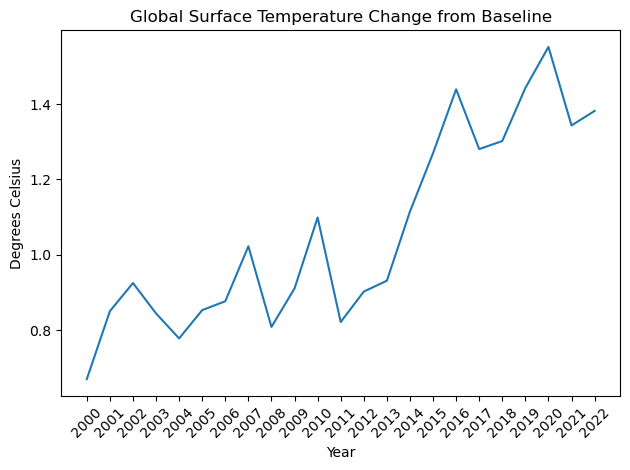

In [35]:
years = np.arange(2000, 2023)
y = global_averages_by_year.values

plt.plot(years, y)
plt.title("Global Surface Temperature Change from Baseline")
plt.xlabel("Year")
plt.ylabel("Degrees Celsius")
plt.xticks(years, rotation=45)
plt.tight_layout()
plt.show()

## Part 3. Change by Region

After looking at individual countries and the global average, I wanted to break the analysis down by world region to get a more human-scale view of the trends.

The original dataset didn't include region information, so I loaded a second file containing each country's ISO3 code and region.

In [36]:
countries_df = pd.read_csv('data/iso_country_codes.csv')
countries_df.head()

,name,ISO2,ISO3,region
0,Afghanistan,AF,AFG,Asia
1,Åland Islands,AX,ALA,Europe
2,Albania,AL,ALB,Europe
3,Algeria,DZ,DZA,Africa
4,American Samoa,AS,ASM,Oceania


I trimmed this second dataset down to just the `ISO3` and `region` columns, since the country name wasn't needed for the merge.

In [38]:
countries_df = countries_df[['ISO3', 'region']]
countries_df.head()

,ISO3,region
0,AFG,Asia
1,ALA,Europe
2,ALB,Europe
3,DZA,Africa
4,ASM,Oceania


I merged the two datasets together on the `ISO3` code, so each country's temperature data now also included its region.

In [39]:
temp_data_region_df = pd.merge(temp_data_df, countries_df, on='ISO3', how='left')
temp_data_region_df.head()

,Country,ISO2,ISO3,1961,1962,1963,1964,1965,1966,1967,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,region
0,"Afghanistan, Islamic Rep. of",AF,AFG,-0.113,-0.164,0.847,-0.764,-0.244,0.226,-0.371,...,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012,Asia
1,Albania,AL,ALB,0.627,0.326,0.075,-0.166,-0.388,0.559,-0.074,...,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518,Europe
2,Algeria,DZ,DZA,0.164,0.114,0.077,0.250,-0.100,0.433,-0.026,...,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688,Africa
3,American Samoa,AS,ASM,0.079,-0.042,0.169,-0.140,-0.562,0.181,-0.368,...,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256,Oceania
4,"Andorra, Principality of",AD,AND,0.736,0.112,-0.752,0.308,-0.490,0.415,0.637,...,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243,Europe


I confirmed the merge worked correctly by checking the first few rows.

In [40]:
temp_data_region_df.head()

,Country,ISO2,ISO3,1961,1962,1963,1964,1965,1966,1967,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,region
0,"Afghanistan, Islamic Rep. of",AF,AFG,-0.113,-0.164,0.847,-0.764,-0.244,0.226,-0.371,...,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012,Asia
1,Albania,AL,ALB,0.627,0.326,0.075,-0.166,-0.388,0.559,-0.074,...,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518,Europe
2,Algeria,DZ,DZA,0.164,0.114,0.077,0.250,-0.100,0.433,-0.026,...,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688,Africa
3,American Samoa,AS,ASM,0.079,-0.042,0.169,-0.140,-0.562,0.181,-0.368,...,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256,Oceania
4,"Andorra, Principality of",AD,AND,0.736,0.112,-0.752,0.308,-0.490,0.415,0.637,...,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243,Europe


I then grouped the merged data by region and counted how many countries fall into each one.

In [41]:
temp_data_by_region = temp_data_region_df.groupby('region')
countries_per_region = temp_data_by_region['Country'].count()
print(countries_per_region)

region
Africa      56
Americas    48
Asia        50
Europe      47
Oceania     23
Name: Country, dtype: int64


I identified which region had the greatest average temperature increase in 2022.

In [45]:
region_mean_2022 = temp_data_by_region['2022'].mean()
max_val = region_mean_2022.max()
print(region_mean_2022[region_mean_2022 == max_val].index[0])

Europe


I also compared each region's average temperature change between 2000 and 2022 to see which region warmed the most over that period.

In [46]:
region_mean_2000 = temp_data_by_region['2000'].mean()
region_mean_2022 = temp_data_by_region['2022'].mean()
region_diff_2000_2022 = region_mean_2022 - region_mean_2000
print(region_diff_2000_2022)

region
Africa      0.586493
Americas    0.522227
Asia        0.927408
Europe      0.787590
Oceania     0.685250
dtype: float64


I wrote a function, `number_years_warmer`, that compares two regions and counts how many years the first region was warmer (on average) than the second.

In [50]:
region_mean_2022 = temp_data_by_region['2022'].mean()
max_val = region_mean_2022.max()
print(region_mean_2022[region_mean_2022 == max_val].index[0])

Europe


Finally, I visualized temperature change over time for every region on a single line chart, so trends across regions could be compared directly.

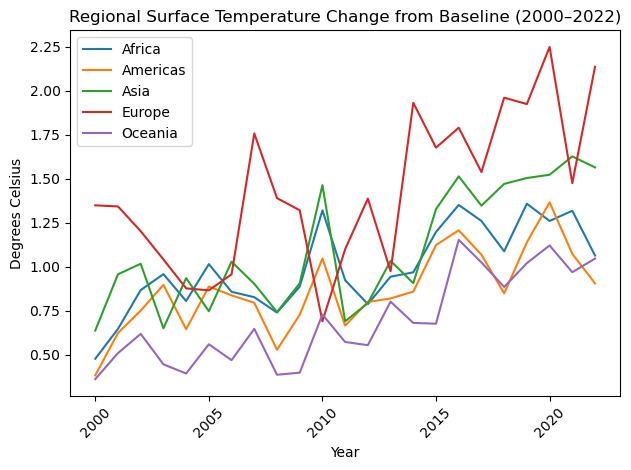

In [51]:
year_cols = []
for y in range(2000, 2023):
    year_cols.append(str(y))

region_year_means = temp_data_region_df.groupby('region')[year_cols].mean()
region_year_means_T = region_year_means.transpose()

region_year_means_T.plot()
plt.title("Regional Surface Temperature Change from Baseline (2000–2022)")
plt.xlabel("Year")
plt.ylabel("Degrees Celsius")
plt.xticks(rotation=45)
plt.legend(list(region_year_means_T.columns))
plt.tight_layout()
plt.show()

Looking at the plot, one conclusion stood out.

In [0]:
# All regions are warming over time, and Europe and also Asia seems to rise the fastest since about 2010.